In [16]:
import pandas as pd
# Load dataset
df = pd.read_csv('../data/fastfood.csv', na_values=[' ', '-', ''])
print(df.head())

display(df.head())
display(df.info())

  restaurant                                       item  calories  cal_fat  \
0  Mcdonalds           Artisan Grilled Chicken Sandwich       380     60.0   
1  Mcdonalds             Single Bacon Smokehouse Burger       840    410.0   
2  Mcdonalds             Double Bacon Smokehouse Burger      1130    600.0   
3  Mcdonalds  Grilled Bacon Smokehouse Chicken Sandwich       750    280.0   
4  Mcdonalds   Crispy Bacon Smokehouse Chicken Sandwich       920    410.0   

   total_fat  sat_fat  trans_fat  cholesterol  sodium  total_carb  fiber  \
0          7      2.0        0.0           95    1110          44    3.0   
1         45     17.0        1.5          130    1580          62    2.0   
2         67     27.0        3.0          220    1920          63    3.0   
3         31     10.0        0.5          155    1940          62    2.0   
4         45     12.0        0.5          120    1980          81    4.0   

   sugar  protein  calcium  
0     11     37.0     20.0  
1     18     46.

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,calcium
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60.0,7,2.0,0.0,95,1110,44,3.0,11,37.0,20.0
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410.0,45,17.0,1.5,130,1580,62,2.0,18,46.0,20.0
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600.0,67,27.0,3.0,220,1920,63,3.0,18,70.0,50.0
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280.0,31,10.0,0.5,155,1940,62,2.0,18,55.0,20.0
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410.0,45,12.0,0.5,120,1980,81,4.0,18,46.0,20.0


<class 'pandas.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   restaurant   512 non-null    str    
 1   item         515 non-null    str    
 2   calories     515 non-null    int64  
 3   cal_fat      514 non-null    float64
 4   total_fat    515 non-null    int64  
 5   sat_fat      515 non-null    float64
 6   trans_fat    515 non-null    float64
 7   cholesterol  515 non-null    int64  
 8   sodium       515 non-null    int64  
 9   total_carb   515 non-null    int64  
 10  fiber        503 non-null    float64
 11  sugar        515 non-null    int64  
 12  protein      513 non-null    float64
 13  calcium      305 non-null    float64
dtypes: float64(6), int64(6), str(2)
memory usage: 56.5 KB


None

In [17]:
# Check for missing values in the dataset

print(df.isna().sum())


# Check if there are empty values represented as:
# empty string, space or '-'

print(df.isin([' ', '-', '']).sum())

restaurant       3
item             0
calories         0
cal_fat          1
total_fat        0
sat_fat          0
trans_fat        0
cholesterol      0
sodium           0
total_carb       0
fiber           12
sugar            0
protein          2
calcium        210
dtype: int64
restaurant     0
item           0
calories       0
cal_fat        0
total_fat      0
sat_fat        0
trans_fat      0
cholesterol    0
sodium         0
total_carb     0
fiber          0
sugar          0
protein        0
calcium        0
dtype: int64


In [18]:
# Create a subset of the dataset.
# Rows with extremely high values of total_fat are removed
# to reduce the influence of extreme values on the regression model.

df_subset = df.loc[
    df['total_fat'] <= 125
].copy()


display(df_subset.head())
display(df_subset.describe())

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,calcium
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60.0,7,2.0,0.0,95,1110,44,3.0,11,37.0,20.0
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410.0,45,17.0,1.5,130,1580,62,2.0,18,46.0,20.0
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600.0,67,27.0,3.0,220,1920,63,3.0,18,70.0,50.0
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280.0,31,10.0,0.5,155,1940,62,2.0,18,55.0,20.0
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410.0,45,12.0,0.5,120,1980,81,4.0,18,46.0,20.0


,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,calcium
count,513.000000,512.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,501.000000,513.000000,511.000000,304.000000
mean,525.224172,234.892578,26.173489,8.046784,0.447368,70.243665,1236.198830,45.600390,4.143713,7.270955,27.334638,24.907895
std,266.414999,155.488266,17.183725,6.157341,0.769384,51.335572,656.899883,24.778751,3.041596,6.771859,15.568053,25.545754
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,330.000000,120.000000,14.000000,4.000000,0.000000,35.000000,800.000000,29.000000,2.000000,3.000000,15.500000,8.000000
50%,490.000000,210.000000,23.000000,7.000000,0.000000,60.000000,1110.000000,44.000000,3.000000,6.000000,24.000000,20.000000
75%,680.000000,310.000000,34.000000,10.000000,1.000000,95.000000,1550.000000,57.000000,5.000000,9.000000,35.000000,31.250000
max,1770.000000,960.000000,107.000000,43.000000,4.000000,335.000000,4520.000000,156.000000,17.000000,87.000000,115.000000,290.000000


In [19]:
# The columns restaurant and item contain textual information
# which does not contribute to predicting protein values,
# therefore they are removed from the dataset.
df_subset.drop(
    columns=['restaurant', 'item'],
    inplace=True
)

In [20]:
#Dropping calcium because it has too many NA values
df_subset.drop(columns='calcium', inplace=True)

In [21]:
from scipy.stats import shapiro
# Columns containing missing values are tested
# using the Shapiro-Wilk test to determine
# whether their distributions are normal.

cols_with_na = [
    'protein',
    'cal_fat',
    'fiber'
]


for col in cols_with_na:

    series = df_subset[col].dropna()

    stat, p = shapiro(series)

    print(
        f'{col}: p={p:.5f} - '
        f'{"not normal" if p < 0.05 else "normal"} distribution'
    )

protein: p=0.00000 - not normal distribution
cal_fat: p=0.00000 - not normal distribution
fiber: p=0.00000 - not normal distribution


In [22]:
# Since the variables do not follow a normal distribution,
# missing values are replaced with the median.
# Median is used because it is less sensitive to outliers
# compared to the mean value.
for col in cols_with_na:
    median = df_subset[col].median()
    df_subset[col] = df_subset[col].fillna(median)

print(df_subset.isna().sum())


calories       0
cal_fat        0
total_fat      0
sat_fat        0
trans_fat      0
cholesterol    0
sodium         0
total_carb     0
fiber          0
sugar          0
protein        0
dtype: int64


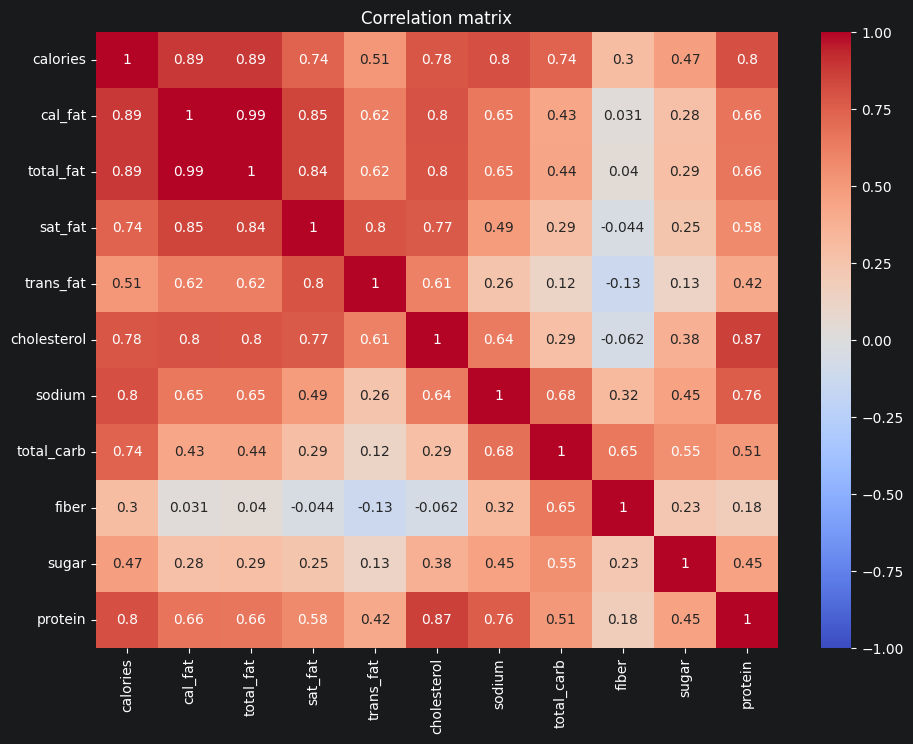

In [24]:
# Create a correlation matrix to analyze relationships
# between numerical attributes.
import matplotlib.pyplot as plt
import seaborn as sb
corr = df_subset.corr(numeric_only=True).round(4)
plt.figure(figsize=(11,8))
sb.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()


# Target variable: protein
# Predictor variables:calories, cholesterol and sodium

# Predictors are selected based on the correlation coefficient.
# Variables with an absolute correlation value greater than 0.5
# are considered to have a strong relationship with the target variable and are included as predictors in the linear regression model.


In [25]:
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets.
# 80% of data is used for training,
# while 20% is used for model evaluation.

train_df, test_df = train_test_split(
    df_subset,
    test_size=0.2,
    random_state=42
)


In [28]:
# Build Linear Regression model using Ordinary Least Squares (OLS) method.
import statsmodels.formula.api as smf
lm = smf.ols(
    formula='protein ~ calories + cholesterol + sodium',
    data=train_df
).fit()

display(lm.summary())


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                protein   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     661.6
Date:                Thu, 06 Aug 2026   Prob (F-statistic):          7.05e-156
Time:                        20:22:21   Log-Likelihood:                -1323.4
No. Observations:                 410   AIC:                             2655.
Df Residuals:                     406   BIC:                             2671.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.9725      0.697      4.267      0.000       1.603       4.342
calories        0.0073      0.002      3.063      0.002       0.003       0.012
cholesterol     0.1928      0.010     19.250      0.000       0.173       0.212
sodium          0.0056      0.001      7.088      0.000       0.004       0.007
==============================================================================
Omnibus:                       77.661   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1311.052
Skew:                          -0.016   Prob(JB):                    2.04e-285
Kurtosis:                      11.760   Cond. No.                     3.43e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.43e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Residuals represent the difference between the actual and predicted values
# of the target variable (protein).
# Ideally, residuals should be evenly distributed around zero.


# The intercept value is 2.9725.
# This means that when all independent variables are equal to zero,
# the expected value of protein is approximately 2.97.


# Coefficients:
# - cholesterol: coefficient 0.1928 → an increase of 1 unit in cholesterol is associated with an increase of approximately 0.1928 units in protein.
# - calories: coefficient 0.0073 → an increase of 1 unit in calories is associated with an increase of approximately 0.0073 units in protein.
# - sodium: coefficient 0.0056 → an increase of 1 unit in sodium is associated with an increase of approximately 0.0056 units in protein.


# Statistical significance:
# - cholesterol and sodium have p-values < 0.001, indicating that they are highly statistically significant predictors.
# - calories has p-value = 0.015, which also indicates statistical significance (p < 0.002).


# The R-squared value is 0.830, meaning that the model explains approximately 83% of the variability in the target variable.


# The F-statistic is high (661.6) and the corresponding p-value is close to zero,indicating that the regression model as a whole is statistically significant.


# Warning: The condition number is 3.43e+03, which may indicate the presence of multicollinearity between predictors.
# Additional analysis, such as calculating Variance Inflation Factor (VIF),is recommended.

In [29]:

y_true = test_df['protein']
X_test = test_df[
    [
        'calories',
        'cholesterol',
        'sodium'
    ]
]


# Generate predictions using trained model
y_pred = lm.predict(X_test)

In [30]:
# Create a dataframe comparing
# actual and predicted values

result = pd.DataFrame(
    {
        'Actual': y_true.values,
        'Predicted': y_pred.values
    }
)


display(result.head(10))

,Actual,Predicted
0,19.0,19.063815
1,13.0,17.521953
2,12.0,15.799268
3,49.0,47.673191
4,14.0,16.817521
5,11.0,17.913780
6,13.0,14.372095
7,23.0,25.473598
8,20.0,21.955434
9,37.0,27.567154


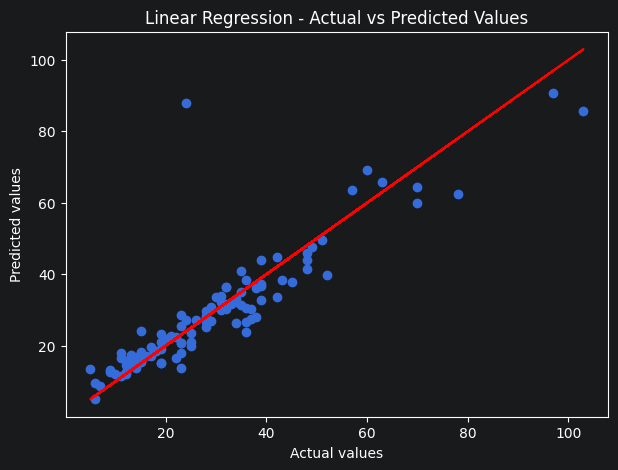

In [33]:
# Visualize relationship between actual
# and predicted values.
plt.figure(figsize=(7,5))
plt.scatter(
    y_true,
    y_pred
)
plt.plot(y_true, y_true,color='red')
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Linear Regression - Actual vs Predicted Values")

plt.show()